<a href="https://colab.research.google.com/github/Bhavyaprathap/AWS/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Domain-Specific Text-to-SQL Fine-Tuning with Qwen2.5-0.5B-Instruct + LoRA/QLoRA

## 1. Project Overview

**Goal:** Adapt an existing instruction-tuned LLM to a specific downstream task
(Natural Language -> SQL) using parameter-efficient fine-tuning (LoRA), and then
study inference behavior (latency, context length, output length) plus a
quantized variant (QLoRA).

This is **not** training a language model from scratch. We start from a model
that already understands language and instructions, and we specialize it.

### Conceptual pipeline (inference)

```
Database Schema + Natural Language Question
                 |
                 v
             Qwen Model
                 |
                 v
             SQL Query
```

### What fine-tuning changes

```
Base Qwen
   |
   v
LoRA Adapter (small set of new trainable weights)
   |
   v
Domain-Adapted Qwen (Base weights frozen + LoRA weights learned)
   |
   v
Better Text-to-SQL behavior (in principle -- we will *measure* this, not assume it)
```

### What kind of fine-tuning is this?

This is **supervised fine-tuning (SFT)**, specifically **instruction fine-tuning**:
we show the model (schema, question) -> (SQL) pairs and train it to reproduce
the target SQL, conditioned on the instruction/prompt. We are not doing:
- Pretraining (learning language from raw text)
- Reinforcement learning from human feedback (RLHF)
- Full fine-tuning of every parameter (we use LoRA instead)

### Full project pipeline

```
Base Qwen model
     |
Baseline inference
     |
Existing Text-to-SQL dataset (b-mc2/sql-create-context)
     |
Small controlled subset (300 train / 50 test)
     |
Dataset formatting (chat template)
     |
LoRA fine-tuning
     |
Save LoRA adapter
     |
Load Base Qwen + LoRA
     |
Evaluate
     |
Compare Base vs LoRA
     |
Latency experiments
     |
Context-length experiments
     |
Output-length experiments
     |
QLoRA (optional, environment-dependent)
     |
Final comparison
     |
Future inference UI (sketch only)
```

### Model and dataset used (fixed, do not substitute)

- Model: `Qwen/Qwen2.5-0.5B-Instruct`
- Dataset: `b-mc2/sql-create-context`

Everything below builds toward two things: (1) a **working** LoRA fine-tuning
pipeline, and (2) **honest, measured** evaluation -- no fabricated numbers.


## 2. Environment Setup

This notebook is designed for **Google Colab**.

Before running anything:
1. In Colab, go to `Runtime -> Change runtime type`.
2. Set **Hardware accelerator** to a GPU (T4 is fine; anything with >= 12GB VRAM works well for a 0.5B model).
3. Run cells **top to bottom** -- later sections depend on variables created earlier (model, tokenizer, dataset, etc.).

We will install a small, pinned-compatible set of libraries:
- `transformers` -- model + tokenizer loading, generation
- `datasets` -- loading `b-mc2/sql-create-context` from the Hugging Face Hub
- `peft` -- LoRA / QLoRA adapter implementation
- `accelerate` -- device placement / mixed precision helpers used by `Trainer`
- `pandas`, `matplotlib` -- results tables and plots

`bitsandbytes` (needed for QLoRA's 4-bit quantization) is installed later,
**only in the QLoRA section**, and only if the environment supports it. We do
this so a missing/incompatible `bitsandbytes` install can never break the main
LoRA pipeline, which is the priority of this project.


## 3. GPU Check

Fine-tuning (even with LoRA) is much faster on a GPU. A GPU is not strictly
required to *load* the model and run small inference tests, but training in
Section 19 will be very slow on CPU.

We check:
- PyTorch version
- CUDA availability
- GPU name (if any)
- GPU memory (if any)

**Why GPU helps:** training involves many matrix multiplications (forward
pass) and their gradients (backward pass). GPUs parallelize these operations
across thousands of cores, which is dramatically faster than a CPU for this
workload.

If no GPU is available, this notebook will still run end-to-end, but training
in Section 19 should be limited to very few steps (we handle this
automatically below) and the QLoRA section will be skipped (QLoRA's speed
benefit requires a CUDA GPU with `bitsandbytes` support).


In [1]:
import torch

print("PyTorch version:", torch.__version__)

CUDA_AVAILABLE = torch.cuda.is_available()
print("CUDA available:", CUDA_AVAILABLE)

if CUDA_AVAILABLE:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print("GPU name:", gpu_name)
    print("GPU memory (GB): %.2f" % gpu_mem_gb)
    DEVICE = "cuda"
else:
    print("No GPU detected. Training will fall back to a very small number of")
    print("steps so the notebook still completes. For a real training run,")
    print("use Runtime -> Change runtime type -> GPU in Colab.")
    DEVICE = "cpu"

print("\nSelected device:", DEVICE)


PyTorch version: 2.11.0+cu128
CUDA available: True
GPU name: Tesla T4
GPU memory (GB): 14.56

Selected device: cuda


## 4. Install Dependencies

We pin roughly compatible, current versions. `bitsandbytes` is intentionally
**not** installed here -- it is only installed later, inside the optional
QLoRA section, so a failure there cannot break the rest of the notebook.


In [2]:
%%capture
!pip3 install -q -U "transformers>=4.44.0" "datasets>=2.19.0" "peft>=0.11.0" \
                    "accelerate>=0.31.0" "pandas" "matplotlib"


In [3]:
# Un-suppressed sanity check that installs succeeded
import transformers, datasets, peft, accelerate
print("transformers:", transformers.__version__)
print("datasets    :", datasets.__version__)
print("peft        :", peft.__version__)
print("accelerate  :", accelerate.__version__)


transformers: 5.15.0
datasets    : 5.0.1
peft        : 0.20.0
accelerate  : 1.14.0


## 5. Import Libraries

All imports used throughout the notebook, gathered in one place so the
dependency surface is explicit and easy to audit.


In [4]:
import os
import json
import time
import random
import sqlite3
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForSeq2Seq,
)
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, PeftModel

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Project directories (created fresh each Colab session)
PROJECT_DIR = "project"
DATA_DIR = os.path.join(PROJECT_DIR, "data")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
PLOTS_DIR = os.path.join(PROJECT_DIR, "plots")
ADAPTER_DIR = os.path.join(PROJECT_DIR, "qwen_sql_lora_adapter")

for d in [PROJECT_DIR, DATA_DIR, RESULTS_DIR, PLOTS_DIR, ADAPTER_DIR]:
    os.makedirs(d, exist_ok=True)

print("Project directories ready:")
for d in [PROJECT_DIR, DATA_DIR, RESULTS_DIR, PLOTS_DIR, ADAPTER_DIR]:
    print(" -", d)


Project directories ready:
 - project
 - project/data
 - project/results
 - project/plots
 - project/qwen_sql_lora_adapter


## 6. Load Qwen2.5-0.5B-Instruct

**Model used (fixed for this project):** `Qwen/Qwen2.5-0.5B-Instruct`

### Background concepts

- **Hugging Face Transformers**: a library providing a uniform Python
  interface to load, run, and fine-tune thousands of pretrained models
  without hand-writing model architecture code.
- **Tokenizer**: converts raw text into integer IDs the model understands
  (and back again). Qwen uses a byte-pair-encoding-style vocabulary.
- **`AutoTokenizer`**: automatically picks the correct tokenizer class and
  vocabulary for the model repo we point it at.
- **`AutoModelForCausalLM`**: automatically picks the correct *causal language
  model* class for the repo. "Causal" means the model predicts the next token
  using only the tokens that came before it (left-to-right), which is the
  standard setup for autoregressive text generation.
- **Instruction-tuned model**: `Qwen2.5-0.5B-Instruct` has already been
  fine-tuned by its creators to follow chat-style instructions (system/user/
  assistant turns), unlike a raw "base" (pretraining-only) model. This means
  it already understands prompts like "Generate only the SQL query...".
- **0.5B parameters**: ~500 million trainable weights in the base model. This
  is a *small* LLM by current standards (compare to 7B-70B+ models). We chose
  it deliberately:
  - It fits comfortably in a free-tier Colab GPU, including full-precision
    loading, LoRA fine-tuning, and inference -- so the whole pipeline
    actually runs end-to-end in this notebook.
  - It trains and generates fast, which matters because we want to run many
    controlled experiments (base vs LoRA, context length, output length,
    LoRA vs QLoRA) within a reasonable time budget.
  - It is instruction-tuned already, so we are doing *targeted adaptation*,
    not teaching it to follow instructions from zero.
  - The trade-off: a 0.5B model has much less raw reasoning/SQL capability
    than a 7B+ model. We are not claiming state-of-the-art Text-to-SQL
    accuracy -- the goal is to understand and demonstrate the *fine-tuning
    and optimization pipeline* end-to-end.

We only **load** the model in this section. No fine-tuning happens yet --
first we verify it loads and inspect it.


In [5]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Qwen2.5's tokenizer does not define a pad token by default; we reuse EOS
# as PAD. This is a common, safe pattern for causal LMs used with padding.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model_dtype = torch.bfloat16 if (CUDA_AVAILABLE and torch.cuda.is_bf16_supported()) else torch.float32

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=model_dtype,
)
base_model.to(DEVICE)

print("Loaded:", MODEL_NAME)
print("dtype used:", model_dtype)
print("device:", DEVICE)


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-0.5B-Instruct
dtype used: torch.bfloat16
device: cuda


## 7. Inspect Model

Before touching training code, let's understand what we actually loaded:
how many parameters it has, its dtype, and its device. We print a *shallow*
module summary rather than the full layer-by-layer dump, since a full dump
for even a 0.5B model is hundreds of lines and adds little understanding.

At a high level, a decoder-only Transformer like Qwen2.5 consists of:
- An **embedding layer** mapping token IDs to vectors.
- A stack of **decoder blocks**, each containing self-attention
  (query/key/value/output projections) and a feed-forward (MLP) block.
- A final **language modeling head** projecting hidden states back to
  vocabulary-sized logits (predicted next-token probabilities).


In [6]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    return total

total_params = count_parameters(base_model)
print("Total parameters: {:,}".format(total_params))
print("Approx size in billions: {:.3f}B".format(total_params / 1e9))
print()
print("Model dtype:", next(base_model.parameters()).dtype)
print("Model device:", next(base_model.parameters()).device)
print()
print("Top-level modules:")
for name, module in base_model.named_children():
    print(" -", name, "->", type(module).__name__)


Total parameters: 494,032,768
Approx size in billions: 0.494B

Model dtype: torch.bfloat16
Model device: cuda:0

Top-level modules:
 - model -> Qwen2Model
 - lm_head -> Linear


## 8. Baseline Inference

We build one small, readable inference function that we will reuse
throughout the notebook (base model, fine-tuned model, all experiments) so
comparisons stay fair.

### Why the chat template matters

`Qwen2.5-0.5B-Instruct` was instruction-tuned using a specific conversation
format (special tokens marking system/user/assistant turns). If we don't use
that exact format, the model receives a prompt that looks unlike anything it
was trained on, and its instruction-following ability degrades sharply.
`tokenizer.apply_chat_template(...)` builds the *correct* Qwen chat format
for us from a plain list of `{"role": ..., "content": ...}` messages, so we
never have to hand-write Qwen's special tokens ourselves.

### Prompt design

```
System:
You are a SQL generation assistant. Generate only the SQL query required to
answer the question using the provided database schema.

User:
Database schema:
{context}

Question:
{question}
```

The function below returns the generated SQL text plus token counts and
wall-clock latency, so every experiment later in the notebook reuses the
same measurement code (this is important for fair comparisons).


In [7]:
SYSTEM_PROMPT = (
    "You are a SQL generation assistant. Generate only the SQL query "
    "required to answer the question using the provided database schema."
)

def build_messages(context, question):
    user_content = "Database schema:\n{}\n\nQuestion:\n{}".format(context, question)
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

def generate_sql(model, tokenizer, context, question, max_new_tokens=64, device=None):
    device = device or DEVICE
    messages = build_messages(context, question)

    prompt_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt_text, return_tensors="pt").to(device)
    input_token_count = inputs["input_ids"].shape[1]

    start = time.time()
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,          # deterministic (greedy) decoding for reproducible comparisons
            pad_token_id=tokenizer.pad_token_id,
        )
    latency_sec = time.time() - start

    new_tokens = output_ids[0][input_token_count:]
    output_token_count = new_tokens.shape[0]
    generated_text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    return {
        "generated_sql": generated_text,
        "input_tokens": input_token_count,
        "output_tokens": output_token_count,
        "latency_sec": latency_sec,
    }


In [8]:
# A few hand-written baseline examples (not from the dataset) to sanity-check behavior
baseline_examples = [
    {
        "context": (
            "CREATE TABLE employees (id INTEGER, name TEXT, salary INTEGER, department TEXT);"
        ),
        "question": "Who has the highest salary?",
    },
    {
        "context": (
            "CREATE TABLE orders (order_id INTEGER, customer_id INTEGER, amount REAL, status TEXT);"
        ),
        "question": "What is the total amount of orders with status 'completed'?",
    },
    {
        "context": (
            "CREATE TABLE students (id INTEGER, name TEXT, grade INTEGER, city TEXT);"
        ),
        "question": "List the names of students in grade 10.",
    },
]

print("=== BASELINE (pre-fine-tuning) generations -- these are NOT assumed correct ===\n")
for ex in baseline_examples:
    result = generate_sql(base_model, tokenizer, ex["context"], ex["question"])
    print("Schema  :", ex["context"])
    print("Question:", ex["question"])
    print("Generated SQL:", result["generated_sql"])
    print("input_tokens={} output_tokens={} latency={:.3f}s".format(
        result["input_tokens"], result["output_tokens"], result["latency_sec"]))
    print("-" * 70)


=== BASELINE (pre-fine-tuning) generations -- these are NOT assumed correct ===

Schema  : CREATE TABLE employees (id INTEGER, name TEXT, salary INTEGER, department TEXT);
Question: Who has the highest salary?
Generated SQL: SELECT name FROM employees ORDER BY salary DESC LIMIT 1
input_tokens=63 output_tokens=12 latency=1.581s
----------------------------------------------------------------------
Schema  : CREATE TABLE orders (order_id INTEGER, customer_id INTEGER, amount REAL, status TEXT);
Question: What is the total amount of orders with status 'completed'?
Generated SQL: SELECT SUM(amount) FROM orders WHERE status = 'completed'
input_tokens=71 output_tokens=13 latency=0.471s
----------------------------------------------------------------------
Schema  : CREATE TABLE students (id INTEGER, name TEXT, grade INTEGER, city TEXT);
Question: List the names of students in grade 10.
Generated SQL: SELECT name FROM students WHERE grade = 10
input_tokens=68 output_tokens=11 latency=0.377s
--

These three generations are our **baseline** reference point. We do not
assume they are correct SQL -- some may be right, some may be malformed or
miss details of the schema. That is expected from a small, un-adapted model
and is exactly the gap we hope LoRA fine-tuning narrows. We measure this gap
formally in Section 19+ rather than eyeballing it here.


## 9. Baseline Latency

Before benchmarking, we must **warm up** the model: the first CUDA call in a
session pays a one-time cost (kernel compilation/caching, memory allocator
warm-up). If we included that first call in our timing, our latency numbers
would be inflated and not representative of steady-state performance.

We then run a few timed generations and report:
- input tokens
- output tokens
- generation latency (seconds)
- tokens/sec (output_tokens / latency_sec)


In [9]:
def warm_up(model, tokenizer, n=2, device=None):
    device = device or DEVICE
    for _ in range(n):
        generate_sql(model, tokenizer,
                     "CREATE TABLE t (a INTEGER, b INTEGER);",
                     "How many rows are there?",
                     max_new_tokens=16, device=device)

warm_up(base_model, tokenizer)

baseline_latency_runs = []
for _ in range(5):
    r = generate_sql(base_model, tokenizer,
                      "CREATE TABLE employees (id INTEGER, name TEXT, salary INTEGER);",
                      "Who has the highest salary?",
                      max_new_tokens=64)
    r["tokens_per_sec"] = r["output_tokens"] / r["latency_sec"] if r["latency_sec"] > 0 else float("nan")
    baseline_latency_runs.append(r)

baseline_latency_df = pd.DataFrame(baseline_latency_runs)
print(baseline_latency_df[["input_tokens", "output_tokens", "latency_sec", "tokens_per_sec"]])
print()
print("Mean latency (s):", baseline_latency_df["latency_sec"].mean())
print("Mean tokens/sec  :", baseline_latency_df["tokens_per_sec"].mean())


   input_tokens  output_tokens  latency_sec  tokens_per_sec
0            60             12     0.398286       30.129131
1            60             12     0.394798       30.395306
2            60             12     0.394411       30.425127
3            60             12     0.391134       30.680058
4            60             12     0.409458       29.307058

Mean latency (s): 0.3976171016693115
Mean tokens/sec  : 30.187336009296207


## 10. Load Dataset

Dataset used: `b-mc2/sql-create-context`
(https://huggingface.co/datasets/b-mc2/sql-create-context)

Each row has three fields:
- **`question`**: a natural-language question about a database.
- **`context`**: the relevant schema, as one or more `CREATE TABLE`
  statements.
- **`answer`**: the target SQL query that answers the question given that
  schema.

This is exactly the (schema, question) -> SQL structure our prompt format
in Section 8 was designed around.


In [10]:
raw_dataset = load_dataset("b-mc2/sql-create-context")
print(raw_dataset)
print()
print("Columns:", raw_dataset["train"].column_names)
print("Total rows in 'train' split (the only split this dataset ships with):",
      len(raw_dataset["train"]))


README.md:   0%|          | 0.00/4.43k [00:00<?, ?B/s]

sql_create_context_v4.json: reconstructing file:   0%|          |  0.00B / 21.8MB            

sql_create_context_v4.json: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/78577 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['answer', 'question', 'context'],
        num_rows: 78577
    })
})

Columns: ['answer', 'question', 'context']
Total rows in 'train' split (the only split this dataset ships with): 78577


## 11. Explore Dataset

Let's look at a full example to make the field meanings concrete.


In [11]:
example = raw_dataset["train"][0]
print("question:")
print(" ", example["question"])
print()
print("context:")
print(" ", example["context"])
print()
print("answer:")
print(" ", example["answer"])


question:
  How many heads of the departments are older than 56 ?

context:
  CREATE TABLE head (age INTEGER)

answer:
  SELECT COUNT(*) FROM head WHERE age > 56


In [12]:
# A quick peek at a few more rows as a table
preview_df = pd.DataFrame(raw_dataset["train"][:5])
preview_df


,answer,question,context
0,SELECT COUNT(*) FROM head WHERE age > 56,How many heads of the departments are older th...,CREATE TABLE head (age INTEGER)
1,"SELECT name, born_state, age FROM head ORDER B...","List the name, born state and age of the heads...","CREATE TABLE head (name VARCHAR, born_state VA..."
2,"SELECT creation, name, budget_in_billions FROM...","List the creation year, name and budget of eac...","CREATE TABLE department (creation VARCHAR, nam..."
3,"SELECT MAX(budget_in_billions), MIN(budget_in_...",What are the maximum and minimum budget of the...,CREATE TABLE department (budget_in_billions IN...
4,SELECT AVG(num_employees) FROM department WHER...,What is the average number of employees of the...,CREATE TABLE department (num_employees INTEGER...


## 12. Create Train/Test Split

We intentionally use a **small, controlled subset**:
- 300 training examples
- 50 test examples

**Why a small subset?** The goal of this project is to demonstrate and
understand the *complete* fine-tuning pipeline (data -> formatting ->
tokenization -> LoRA -> training -> evaluation -> latency/context/output
experiments -> QLoRA) end-to-end, in a Colab session, in a reasonable amount
of time. We are explicitly **not** trying to achieve state-of-the-art
Text-to-SQL accuracy -- that would require far more data, a larger base
model, and much longer training.

### Key concepts
- **Training set**: examples the model's weights are updated on.
- **Test set**: examples held out from training, used only to *measure*
  performance on unseen inputs.
- **Data leakage**: when test examples (or things too similar to them) end
  up in the training set, performance numbers become misleadingly optimistic
  because the model is partly "graded on questions it has seen the answers
  to." We avoid this by shuffling once, with a fixed seed, and slicing train
  and test from disjoint index ranges.
- **Why we need unseen examples**: only performance on data the model never
  trained on tells us whether it generalized, rather than merely memorized.


In [13]:
N_TRAIN = 300
N_TEST = 50

full_data = raw_dataset["train"].shuffle(seed=SEED)

assert N_TRAIN + N_TEST <= len(full_data), "Requested subset larger than dataset."

train_subset = full_data.select(range(N_TRAIN))
test_subset = full_data.select(range(N_TRAIN, N_TRAIN + N_TEST))

# Explicit leakage check: no shared (question, context, answer) rows between splits
train_keys = set(zip(train_subset["question"], train_subset["context"], train_subset["answer"]))
test_keys = set(zip(test_subset["question"], test_subset["context"], test_subset["answer"]))
overlap = train_keys.intersection(test_keys)

print("Train size:", len(train_subset))
print("Test size :", len(test_subset))
print("Overlapping rows between train and test:", len(overlap))
assert len(overlap) == 0, "Data leakage detected between train and test sets!"


Train size: 300
Test size : 50
Overlapping rows between train and test: 0


## 13. Format Dataset

We convert each `(context, question, answer)` triple into Qwen's chat format
using the **tokenizer's own chat template** -- we never hand-write Qwen's
special tokens. For training, the "assistant" turn is the target SQL
(`answer`); at inference time we only build the prompt up through the
generation cue and let the model produce the assistant turn itself.

Conceptually:

```
System:
You are a SQL generation assistant. Generate only the SQL query needed to
answer the user's question using the provided database schema.

User:
Database schema:
{context}

Question:
{question}

Assistant:
{answer}
```


In [14]:
def build_training_text(context, question, answer):
    messages = build_messages(context, question)
    # Prompt portion: everything up to (and including) the assistant generation cue
    prompt_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    # Full text: prompt + target answer + end-of-sequence token
    full_text = prompt_text + answer.strip() + tokenizer.eos_token
    return prompt_text, full_text

# Show one formatted example end-to-end
sample = train_subset[0]
prompt_text, full_text = build_training_text(sample["context"], sample["question"], sample["answer"])
print("----- PROMPT PORTION (model input at inference time) -----")
print(prompt_text)
print("----- FULL TRAINING TEXT (prompt + target answer) -----")
print(full_text)


----- PROMPT PORTION (model input at inference time) -----
<|im_start|>system
You are a SQL generation assistant. Generate only the SQL query required to answer the question using the provided database schema.<|im_end|>
<|im_start|>user
Database schema:
CREATE TABLE table_name_50 (venue VARCHAR, away_team VARCHAR)

Question:
When Essendon played away; where did they play?<|im_end|>
<|im_start|>assistant

----- FULL TRAINING TEXT (prompt + target answer) -----
<|im_start|>system
You are a SQL generation assistant. Generate only the SQL query required to answer the question using the provided database schema.<|im_end|>
<|im_start|>user
Database schema:
CREATE TABLE table_name_50 (venue VARCHAR, away_team VARCHAR)

Question:
When Essendon played away; where did they play?<|im_end|>
<|im_start|>assistant
SELECT venue FROM table_name_50 WHERE away_team = "essendon"<|im_end|>


**What exactly happens during formatting:**
1. We build the same system+user message structure used at inference time
   (Section 8), so training and inference prompts match exactly.
2. `apply_chat_template(..., add_generation_prompt=True)` appends Qwen's
   special "now the assistant should respond" marker -- this is the boundary
   between *prompt* and *target*.
3. We append the ground-truth SQL (`answer`) plus an end-of-sequence token,
   so the model learns not only to produce correct SQL but also **when to
   stop generating**.


## 14. Tokenization

Key concepts:
- **Tokens**: sub-word units the tokenizer splits text into.
- **`input_ids`**: integer IDs for each token -- what the model actually
  consumes.
- **`attention_mask`**: 1 for real tokens, 0 for padding tokens; tells the
  model which positions to actually attend to.
- **`labels`**: the target IDs used to compute the training loss. We set
  labels for the **prompt portion to `-100`** (PyTorch's convention for
  "ignore this position in the loss"), so the model is only ever trained to
  predict the **answer** tokens, not to reproduce the schema/question we fed
  it. If we didn't mask the prompt, the model would waste capacity learning
  to predict input text it will always be given anyway.
- **Padding**: shorter sequences in a batch are padded to match the longest
  sequence in that batch, so they can be stacked into a single tensor.
- **Truncation**: sequences longer than our chosen max length are cut off,
  to bound memory/compute.
- **Max sequence length**: chosen based on the token-length distribution we
  measure in Section 15, not guessed blindly.

We build a small custom `torch.utils.data.Dataset` so the prompt-masking
logic (the most important and easiest-to-get-wrong part of SFT) is fully
visible, not hidden inside a large helper function.


In [15]:
class TextToSQLDataset(Dataset):
    def __init__(self, hf_split, tokenizer, max_length):
        self.examples = hf_split
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        row = self.examples[idx]
        prompt_text, full_text = build_training_text(row["context"], row["question"], row["answer"])

        full_ids = self.tokenizer(
            full_text, truncation=True, max_length=self.max_length
        )["input_ids"]

        prompt_len = len(self.tokenizer(
            prompt_text, truncation=True, max_length=self.max_length
        )["input_ids"])

        labels = list(full_ids)
        # Mask the prompt portion so loss is only computed on the answer tokens
        for i in range(min(prompt_len, len(labels))):
            labels[i] = -100

        return {
            "input_ids": full_ids,
            "attention_mask": [1] * len(full_ids),
            "labels": labels,
        }


## 15. Token Length Analysis

We inspect the token-length distribution of our formatted training examples
*before* picking `MAX_SEQ_LEN`, instead of guessing a large number. Longer
sequences cost more memory (self-attention scales roughly quadratically with
sequence length) and more compute per training step, so we want the smallest
length that comfortably covers our data.


Token length stats over 300 formatted training examples:
 min   : 76
 mean  : 103.5
 median: 100
 p95   : 135
 max   : 182


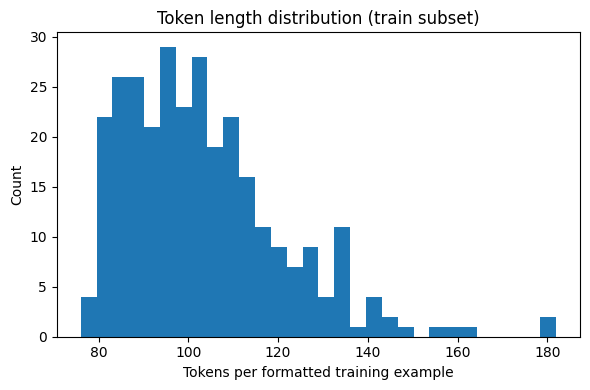

In [16]:
lengths = []
for row in train_subset:
    _, full_text = build_training_text(row["context"], row["question"], row["answer"])
    n_tokens = len(tokenizer(full_text)["input_ids"])
    lengths.append(n_tokens)

lengths = np.array(lengths)
print("Token length stats over {} formatted training examples:".format(len(lengths)))
print(" min   :", lengths.min())
print(" mean  : {:.1f}".format(lengths.mean()))
print(" median:", int(np.median(lengths)))
print(" p95   :", int(np.percentile(lengths, 95)))
print(" max   :", lengths.max())

plt.figure(figsize=(6, 4))
plt.hist(lengths, bins=30)
plt.xlabel("Tokens per formatted training example")
plt.ylabel("Count")
plt.title("Token length distribution (train subset)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "token_length_distribution.png"))
plt.show()


In [17]:
# Choose MAX_SEQ_LEN to comfortably cover ~p95+ of examples without being wastefully large
MAX_SEQ_LEN = int(min(512, max(128, np.percentile(lengths, 99) + 16)))
print("Chosen MAX_SEQ_LEN:", MAX_SEQ_LEN)


Chosen MAX_SEQ_LEN: 174


## 16. LoRA Theory

### Full fine-tuning vs. parameter-efficient fine-tuning

**Full fine-tuning** updates *every* weight in the model. For even a 0.5B
model this means optimizer states (e.g. Adam keeps two extra numbers per
weight) for hundreds of millions of parameters -- expensive in memory, and
risky in terms of overfitting/forgetting when the fine-tuning dataset is
small (like our 300 examples).

**Parameter-efficient fine-tuning (PEFT)** freezes the base model and adds a
small number of new, trainable parameters. **LoRA** (Low-Rank Adaptation) is
the most widely used PEFT method.

### The core idea

For a frozen weight matrix `W` (e.g. an attention projection), full
fine-tuning would learn an update `ΔW` of the *same shape* as `W`:

```
W' = W + ΔW
```

LoRA's insight: instead of learning a full-rank `ΔW`, learn it as the
product of two small, **low-rank** matrices `A` and `B`:

```
ΔW = B @ A       where A is (r x d_in), B is (d_out x r), and r << d_in, d_out
```

So the adapted computation becomes:

```
h = W x + (B A) x = W x + B (A x)
```

- `W` stays **frozen** (never updated).
- Only `A` and `B` are **trainable**.
- `r` (the "rank") controls how expressive the update can be -- and how many
  new parameters we add. Because `r` is small (e.g. 8-32) relative to the
  matrix dimensions (often in the hundreds/thousands for LLM layers), the
  number of trainable parameters in `A` and `B` combined is a **tiny
  fraction** of the number of parameters in `W`.

### Why this matters in practice

- Far fewer trainable parameters -> far less GPU memory needed for gradients
  and optimizer states.
- Faster training steps.
- The **base model's original knowledge is preserved** (it's frozen), which
  reduces the risk of "catastrophic forgetting" from fine-tuning on a small,
  narrow dataset.
- Multiple small LoRA adapters can be trained for different tasks and swapped
  in/out of the same frozen base model.


## 17. LoRA Configuration

Before choosing `target_modules`, we **inspect the actual module names**
inside Qwen2.5-0.5B-Instruct rather than guessing. LoRA is normally applied
to the linear projection layers inside self-attention (and optionally the
MLP), since these are the layers that most directly control how the model
attends to and combines information.


In [18]:
linear_module_names = set()
for name, module in base_model.named_modules():
    if isinstance(module, torch.nn.Linear):
        # keep only the last path component, e.g. "model.layers.3.self_attn.q_proj" -> "q_proj"
        linear_module_names.add(name.split(".")[-1])

print("Distinct Linear module names found in Qwen2.5-0.5B-Instruct:")
for n in sorted(linear_module_names):
    print(" -", n)


Distinct Linear module names found in Qwen2.5-0.5B-Instruct:
 - down_proj
 - gate_proj
 - k_proj
 - lm_head
 - o_proj
 - q_proj
 - up_proj
 - v_proj


Qwen2.5's attention block exposes `q_proj`, `k_proj`, `v_proj`, `o_proj`
(query/key/value/output projections). We target these four:

- They are the layers that compute *how tokens attend to each other* --
  directly relevant to a task like Text-to-SQL where the model must map
  specific schema tokens (table/column names) to the right positions in the
  generated query.
- Targeting attention projections (rather than also the larger MLP
  `gate_proj`/`up_proj`/`down_proj` layers) keeps the adapter small and fast
  to train, which fits our small-subset, fast-iteration goal. This is also
  the most common, well-validated default for LoRA on decoder-only LLMs.

### `LoraConfig` parameters explained
- **`r`**: the rank of the low-rank update matrices (see Section 16). Larger
  `r` = more expressive adapter, but more trainable parameters. We use a
  modest value appropriate for a small model + small dataset.
- **`lora_alpha`**: a scaling factor applied to the LoRA update
  (`scaling = lora_alpha / r`). It controls how strongly the adapter's
  output is weighted relative to the frozen base output. A common heuristic
  is `lora_alpha = 2 * r`.
- **`lora_dropout`**: dropout applied to the LoRA path during training, as a
  light regularizer against overfitting -- especially relevant given our
  small 300-example training set.
- **`target_modules`**: which `Linear` layers get wrapped with a LoRA
  adapter (chosen above from actual inspected module names).
- **`bias`**: whether/how bias terms are trained. `"none"` means we do not
  train any bias parameters -- keeps the adapter minimal and is the standard
  default.
- **`task_type`**: tells PEFT how to wrap the model (`CAUSAL_LM` matches
  `AutoModelForCausalLM`, ensuring PEFT wires up generation correctly).


In [19]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    task_type="CAUSAL_LM",
)
print(lora_config)


LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.20.0', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'o_proj', 'v_proj', 'q_proj', 'k_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)


In [21]:
!pip3 uninstall -y torchao
!pip3 install -U peft transformers accelerate

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


## 18. Apply LoRA

`get_peft_model` wraps the base model: it **freezes all original weights**
and inserts trainable LoRA `A`/`B` matrices into the target modules we
specified. Everything else about the model (architecture, forward pass
logic) is unchanged -- we've only added a small number of new, trainable
parameters alongside the frozen originals.


In [22]:
lora_model = get_peft_model(base_model, lora_config)
lora_model.to(DEVICE)
print("LoRA adapter applied.")


LoRA adapter applied.


## 19. Trainable Parameter Analysis

This is one of the most important numbers in the whole project: how much did
LoRA actually reduce the number of trainable parameters?

**Before LoRA:** if we fine-tuned the base model directly, essentially *all*
~0.5B parameters would be trainable.

**After LoRA:** the base model's parameters are frozen (`requires_grad=False`);
only the small LoRA `A`/`B` matrices we just inserted are trainable
(`requires_grad=True`).


In [23]:
trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in lora_model.parameters())
trainable_pct = 100 * trainable_params / total_params

print("Total parameters     : {:,}".format(total_params))
print("Trainable parameters : {:,}".format(trainable_params))
print("Trainable percentage : {:.4f}%".format(trainable_pct))

# PEFT's own convenience summary (cross-check against our manual computation above)
lora_model.print_trainable_parameters()


Total parameters     : 496,195,456
Trainable parameters : 2,162,688
Trainable percentage : 0.4359%
trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359


## 20. Fine-Tuning

We use Hugging Face's plain `Trainer` (rather than TRL's `SFTTrainer`) so the
full training pipeline -- dataset, collator, masked labels, loss -- stays
directly visible in this notebook, and to avoid coupling to `trl`'s
fast-moving API. Everything `SFTTrainer` would do internally (formatting,
tokenizing, label masking, batching) we've already written explicitly in
Sections 13-15, so using plain `Trainer` here does not hide any logic.

### What happens during training (conceptually)
1. **Forward pass**: a batch of tokenized examples is fed through the model,
   producing predicted next-token logits at every position.
2. **Loss (cross-entropy)**: at each *answer* position (prompt positions are
   masked to `-100` and ignored), we compare the predicted distribution over
   the vocabulary to the actual next token, and compute cross-entropy loss --
   how "surprised" the model was by the correct token.
3. **Backpropagation**: gradients of the loss are computed with respect to
   every trainable parameter. Because the base weights are frozen, gradients
   only flow into (and are only computed for) the LoRA `A`/`B` matrices.
4. **Optimizer step**: the optimizer (AdamW) uses those gradients, scaled by
   the **learning rate**, to update the trainable LoRA parameters.
5. Repeat over **batches** until we've seen the whole training set once
   (one **epoch**), then repeat for a few epochs.

### Key hyperparameters
- **Batch size**: how many examples are processed per forward/backward pass.
  We keep this small since we're on a single, likely modest, GPU.
- **Gradient accumulation**: simulates a larger effective batch size by
  accumulating gradients over several small batches before taking an
  optimizer step -- useful when GPU memory limits the batch size we can fit
  directly.
- **Learning rate**: step size for parameter updates. LoRA adapters are
  typically trained with a *higher* learning rate than full fine-tuning,
  since we're updating far fewer parameters from a random initialization.
- **Epochs**: number of full passes over the training data. With only 300
  examples we use just a few epochs to avoid overfitting/memorizing this
  small subset.
- **Mixed precision**: using lower-precision arithmetic (bf16/fp16) for
  parts of training to save memory/time. We only enable it when the GPU
  actually supports it (checked below), never assumed.

We verify that **only LoRA parameters** receive gradient updates, and we
deliberately keep training short (few epochs over a small dataset) -- this
project prioritizes a *working, understandable* pipeline over maximizing
accuracy.


In [24]:
train_dataset = TextToSQLDataset(train_subset, tokenizer, MAX_SEQ_LEN)

# Sanity-check one item: labels should be -100 for the prompt, real ids for the answer
sample_item = train_dataset[0]
n_masked = sum(1 for l in sample_item["labels"] if l == -100)
n_total = len(sample_item["labels"])
print("Example 0: {} of {} label positions are masked (prompt), {} are trainable (answer).".format(
    n_masked, n_total, n_total - n_masked))


Example 0: 67 of 84 label positions are masked (prompt), 17 are trainable (answer).


In [25]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=-100,
)

use_bf16 = CUDA_AVAILABLE and torch.cuda.is_bf16_supported()
use_fp16 = CUDA_AVAILABLE and not use_bf16

# If there is no GPU, keep this extremely small so the notebook still finishes;
# with a GPU, this trains all 300 examples for a real (if modest) number of steps.
num_epochs = 2 if CUDA_AVAILABLE else 1
max_steps = -1 if CUDA_AVAILABLE else 10  # cap steps on CPU only, so the demo still completes

training_args = TrainingArguments(
    output_dir=os.path.join(PROJECT_DIR, "trainer_checkpoints"),
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    num_train_epochs=num_epochs,
    max_steps=max_steps,
    learning_rate=2e-4,
    logging_steps=10,
    save_strategy="no",
    report_to=[],
    bf16=use_bf16,
    fp16=use_fp16,
    seed=SEED,
)

trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
)

print("bf16:", use_bf16, "| fp16:", use_fp16, "| epochs:", num_epochs, "| max_steps:", max_steps)


bf16: True | fp16: False | epochs: 2 | max_steps: -1


In [26]:
train_result = trainer.train()
print(train_result)


Step,Training Loss
10,0.177680
20,0.152595
30,0.103695
40,0.126840
50,0.069022
60,0.063626
70,0.075039


TrainOutput(global_step=76, training_loss=0.1063130646944046, metrics={'train_runtime': 110.9972, 'train_samples_per_second': 5.406, 'train_steps_per_second': 0.685, 'total_flos': 160039824384000.0, 'train_loss': 0.1063130646944046, 'epoch': 2.0})


## 21. Save LoRA Adapter

We save **only the LoRA adapter**, not a full copy of the base model. This
produces:
- `adapter_model.safetensors` -- the trained LoRA `A`/`B` weight tensors.
- `adapter_config.json` -- the `LoraConfig` used (rank, alpha, target
  modules, etc.), needed to correctly re-attach the adapter later.

**Why save the adapter separately?** The base model (~0.5B params, ~1-2GB)
is unchanged and can always be re-downloaded from the Hub. The adapter is
tiny by comparison (a few MB, since only `r x d` matrices were trained) and
is the only artifact that is *specific to our fine-tuning run*. This is the
same pattern used in production: ship a small adapter, not a full duplicated
model, per fine-tuned task/customer.


In [27]:
lora_model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print("Saved LoRA adapter to:", ADAPTER_DIR)
print("Files:")
for f in os.listdir(ADAPTER_DIR):
    path = os.path.join(ADAPTER_DIR, f)
    size_kb = os.path.getsize(path) / 1024
    print(" - {} ({:.1f} KB)".format(f, size_kb))


Saved LoRA adapter to: project/qwen_sql_lora_adapter
Files:
 - tokenizer_config.json (0.7 KB)
 - adapter_config.json (1.1 KB)
 - adapter_model.safetensors (8472.7 KB)
 - tokenizer.json (11154.3 KB)
 - chat_template.jinja (2.4 KB)
 - README.md (5.1 KB)


## 22. Reload Base + LoRA

To prove the adapter is truly self-contained and reusable, we reload a
**fresh copy of the base model** and attach the saved adapter to it,
independent of the `lora_model` object already in memory.

```
Base Model  +  LoRA Adapter  =  Fine-Tuned Model
```


In [28]:
fresh_base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=model_dtype,
)
fresh_base_model.to(DEVICE)

finetuned_model = PeftModel.from_pretrained(fresh_base_model, ADAPTER_DIR)
finetuned_model.to(DEVICE)
finetuned_model.eval()

print("Reloaded base model + LoRA adapter from disk as `finetuned_model`.")


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Reloaded base model + LoRA adapter from disk as `finetuned_model`.


## 23. Fine-Tuned Inference

We run the fine-tuned model on **held-out test questions** (the 50 examples
never seen during training) and print, for each: the question, the
reference SQL, the generated SQL, latency, and token counts.


In [29]:
warm_up(finetuned_model, tokenizer)

print("=== Fine-tuned model on held-out TEST examples ===\n")
for row in test_subset.select(range(5)):
    result = generate_sql(finetuned_model, tokenizer, row["context"], row["question"])
    print("Question :", row["question"])
    print("Reference:", row["answer"])
    print("Generated:", result["generated_sql"])
    print("latency={:.3f}s input_tokens={} output_tokens={}".format(
        result["latency_sec"], result["input_tokens"], result["output_tokens"]))
    print("-" * 70)


=== Fine-tuned model on held-out TEST examples ===

Question : WHAT IS THE PLACE WITH PLAYER mark o'meara?
Reference: SELECT place FROM table_name_78 WHERE player = "mark o'meara"
Generated: SELECT place FROM table_name_78 WHERE player = "mark o'meara"
latency=1.003s input_tokens=67 output_tokens=19
----------------------------------------------------------------------
Question :  how many candidates with district being california 7
Reference: SELECT COUNT(candidates) FROM table_1342359_5 WHERE district = "California 7"
Generated: SELECT COUNT(candidates) FROM table_1342359_5 WHERE district = "California 7"
latency=1.336s input_tokens=73 output_tokens=26
----------------------------------------------------------------------
Question : Name the genre for release-year of firsst charted less than 1980 and origin of jamaica
Reference: SELECT genre FROM table_name_92 WHERE release_year_of_first_charted_record < 1980 AND country_of_origin = "jamaica"
Generated: SELECT genre FROM table_name_9

## 24. Base vs LoRA Evaluation

We now run **the entire 50-example test set** through both the original
base model and the fine-tuned (base+LoRA) model, using identical prompts and
identical generation settings (`max_new_tokens`, greedy decoding) for a fair
comparison, and record everything in one dataframe.


In [32]:
def evaluate_on_test_set(model, tokenizer, test_data, max_new_tokens=64, label=""):
    rows = []
    for row in test_data:
        result = generate_sql(model, tokenizer, row["context"], row["question"],
                               max_new_tokens=max_new_tokens)
        rows.append({
            "question": row["question"],
            "context": row["context"],
            "reference_sql": row["answer"],
            "{}_generated_sql".format(label): result["generated_sql"],
            "{}_latency".format(label): result["latency_sec"],
            "{}_input_tokens".format(label): result["input_tokens"],
            "{}_output_tokens".format(label): result["output_tokens"],
        })
    return pd.DataFrame(rows)

print("Running base model over full test set...")
base_eval_df = evaluate_on_test_set(base_model, tokenizer, test_subset, label="base")

print("Running LoRA (fine-tuned) model over full test set...")
lora_eval_df = evaluate_on_test_set(finetuned_model, tokenizer, test_subset, label="lora")

eval_df = base_eval_df.merge(
    lora_eval_df.drop(columns=["context", "reference_sql"]),
    on="question",
)

eval_df = eval_df[[
    "question", "context", "reference_sql",
    "base_generated_sql", "lora_generated_sql",
    "base_latency", "lora_latency",
    "base_input_tokens", "lora_input_tokens",
    "base_output_tokens", "lora_output_tokens",
]]

eval_df.to_csv(os.path.join(RESULTS_DIR, "base_vs_lora_eval.csv"), index=False)
eval_df.head(10)


Running base model over full test set...
Running LoRA (fine-tuned) model over full test set...


,question,context,reference_sql,base_generated_sql,lora_generated_sql,base_latency,lora_latency,base_input_tokens,lora_input_tokens,base_output_tokens,lora_output_tokens
0,WHAT IS THE PLACE WITH PLAYER mark o'meara?,"CREATE TABLE table_name_78 (place VARCHAR, pla...",SELECT place FROM table_name_78 WHERE player =...,SELECT place FROM table_name_78 WHERE player =...,SELECT place FROM table_name_78 WHERE player =...,3.471971,1.005702,67,67,19,19
1,how many candidates with district being calif...,CREATE TABLE table_1342359_5 (candidates VARCH...,SELECT COUNT(candidates) FROM table_1342359_5 ...,SELECT COUNT(candidates) FROM table_1342359_5 ...,SELECT COUNT(candidates) FROM table_1342359_5 ...,3.918121,1.311978,73,73,26,26
2,Name the genre for release-year of firsst char...,"CREATE TABLE table_name_92 (genre VARCHAR, rel...",SELECT genre FROM table_name_92 WHERE release_...,SELECT genre FROM table_name_92 WHERE release_...,SELECT genre FROM table_name_92 WHERE release_...,2.666579,1.719244,91,91,33,33
3,How many counties have a place name of Macedonia?,"CREATE TABLE table_249512_2 (a_ VARCHAR, count...",SELECT COUNT(county_ies__)[a_] FROM table_2495...,SELECT COUNT(a_.county_ies__) FROM table_24951...,SELECT COUNT(a_.county_ies__) FROM table_24951...,1.637257,1.490473,78,78,29,29
4,"What is Number of Contestants, when Cycle is 4?",CREATE TABLE table_name_81 (number_of_contesta...,SELECT number_of_contestants FROM table_name_8...,SELECT number_of_contestants FROM table_name_8...,SELECT number_of_contestants FROM table_name_8...,1.074762,0.972844,72,72,19,19
5,What is the total amount of allied-unrelated w...,CREATE TABLE table_11944282_1 (allied_unrelate...,SELECT COUNT(allied_unrelated) FROM table_1194...,SELECT COUNT(allied_unrelated) FROM table_1194...,SELECT COUNT(allied_unrelated) FROM table_1194...,1.636844,1.554425,81,81,28,28
6,What is the lowest number of people in attenda...,"CREATE TABLE table_name_7 (attendance INTEGER,...",SELECT MIN(attendance) FROM table_name_7 WHERE...,SELECT MIN(attendance) FROM table_name_7 WHERE...,SELECT MIN(attendance) FROM table_name_7 WHERE...,1.427219,1.357297,73,73,20,20
7,"For the Loss of Plesac (1-5), what is the Record?","CREATE TABLE table_name_18 (record VARCHAR, lo...",SELECT record FROM table_name_18 WHERE loss = ...,SELECT record FROM table_name_18 WHERE loss = ...,SELECT record FROM table_name_18 WHERE loss = ...,1.296049,1.330113,72,72,20,20
8,What is the capital of the province with 양주 in...,"CREATE TABLE table_name_21 (capital VARCHAR, h...",SELECT capital FROM table_name_21 WHERE hangul...,SELECT capital FROM table_name_21 WHERE hangul...,SELECT capital FROM table_name_21 WHERE hangul...,0.938488,0.894925,71,71,17,17
9,What is the home team with the ny rangers as t...,"CREATE TABLE table_name_16 (home VARCHAR, visi...",SELECT home FROM table_name_16 WHERE visitor =...,SELECT home FROM table_name_16 WHERE visitor =...,SELECT home FROM table_name_16 WHERE visitor =...,0.950499,0.872838,70,70,17,17


## 25. SQL Correctness Evaluation

We report three different, increasingly informative notions of "correct":

1. **Exact Match**: does the generated SQL, after light normalization
   (lowercasing, whitespace collapsing, trailing-semicolon stripping),
   string-match the reference SQL exactly? This is strict and easy to
   compute, but **too strict in practice** -- there are usually many
   syntactically different SQL queries that are semantically equivalent
   (e.g. different column ordering, `AS` alias differences, `SELECT *`
   vs explicit columns). Exact match under-counts correct queries.

2. **SQL Validity (execution-based)**: `b-mc2/sql-create-context` gives us a
   schema (`CREATE TABLE ...`) but **no actual row data**. So we can create
   the table(s) in an in-memory SQLite database and try to **execute** the
   generated SQL against that empty schema. This tells us whether the SQL is
   syntactically valid and references real columns/tables -- it does **not**
   tell us whether the query would return the right *rows*, because there is
   no data to check results against. We report this explicitly as "SQL
   validity", not "execution accuracy", to avoid overstating what this
   metric measures.

3. We do **not** compute a true "execution accuracy" (matching result rows)
   here, since that requires populated tables with known contents, which
   this dataset does not provide. This limitation is intentional to flag
   rather than hide.

All numbers below come directly from the `eval_df` produced in Section 24 --
nothing here is a fabricated or assumed result.


In [33]:
def normalize_sql(sql):
    s = sql.strip().lower()
    s = s.rstrip(";").strip()
    s = re.sub(r"\s+", " ", s)
    return s

def exact_match(generated, reference):
    return normalize_sql(generated) == normalize_sql(reference)

def is_sql_valid_against_schema(sql, schema_sql):
    # Executes the schema's CREATE TABLE statement(s) in a throwaway in-memory
    # SQLite DB, then tries to execute the generated SQL against it.
    # Returns True only if execution succeeds without raising an error.
    conn = sqlite3.connect(":memory:")
    try:
        cur = conn.cursor()
        cur.executescript(schema_sql)
        cur.execute(sql)
        return True
    except Exception:
        return False
    finally:
        conn.close()

eval_df["base_exact_match"] = eval_df.apply(
    lambda r: exact_match(r["base_generated_sql"], r["reference_sql"]), axis=1)
eval_df["lora_exact_match"] = eval_df.apply(
    lambda r: exact_match(r["lora_generated_sql"], r["reference_sql"]), axis=1)

eval_df["base_sql_valid"] = eval_df.apply(
    lambda r: is_sql_valid_against_schema(r["base_generated_sql"], r["context"]), axis=1)
eval_df["lora_sql_valid"] = eval_df.apply(
    lambda r: is_sql_valid_against_schema(r["lora_generated_sql"], r["context"]), axis=1)

base_exact_match_acc = eval_df["base_exact_match"].mean()
lora_exact_match_acc = eval_df["lora_exact_match"].mean()
base_sql_valid_rate = eval_df["base_sql_valid"].mean()
lora_sql_valid_rate = eval_df["lora_sql_valid"].mean()

print("Base  - exact match: {:.1%} | SQL validity: {:.1%}".format(base_exact_match_acc, base_sql_valid_rate))
print("LoRA  - exact match: {:.1%} | SQL validity: {:.1%}".format(lora_exact_match_acc, lora_sql_valid_rate))

eval_df.to_csv(os.path.join(RESULTS_DIR, "base_vs_lora_eval.csv"), index=False)


Base  - exact match: 54.0% | SQL validity: 88.0%
LoRA  - exact match: 54.0% | SQL validity: 88.0%


## 26. Latency Benchmark

A reproducible micro-benchmark, run separately for base and fine-tuned
models, using the **same prompt, same `max_new_tokens`, same decoding
settings**, with warm-up runs excluded from timing and multiple trials
averaged.

Concepts:
- **Prefill**: the forward pass over the *entire input prompt* at once, to
  build up the model's internal key/value cache before generation starts.
- **TTFT (time-to-first-token)**: how long prefill (plus producing the first
  output token) takes -- relevant for interactive/streaming applications.
- **Decoding**: the autoregressive loop that generates output tokens one at
  a time after prefill, each new token depending on all previous ones.
- **Total generation latency**: prefill + decoding time for the full output.


In [34]:
def benchmark_model(model, tokenizer, context, question, max_new_tokens=64, n_trials=5):
    warm_up(model, tokenizer)
    trials = []
    for _ in range(n_trials):
        r = generate_sql(model, tokenizer, context, question, max_new_tokens=max_new_tokens)
        r["tokens_per_sec"] = r["output_tokens"] / r["latency_sec"] if r["latency_sec"] > 0 else float("nan")
        trials.append(r)
    df = pd.DataFrame(trials)
    return df

bench_context = "CREATE TABLE employees (id INTEGER, name TEXT, salary INTEGER, department TEXT);"
bench_question = "Who has the highest salary?"

base_bench_df = benchmark_model(base_model, tokenizer, bench_context, bench_question)
lora_bench_df = benchmark_model(finetuned_model, tokenizer, bench_context, bench_question)

print("BASE  mean latency: {:.3f}s | median: {:.3f}s | tokens/sec: {:.1f}".format(
    base_bench_df["latency_sec"].mean(), base_bench_df["latency_sec"].median(),
    base_bench_df["tokens_per_sec"].mean()))
print("LORA  mean latency: {:.3f}s | median: {:.3f}s | tokens/sec: {:.1f}".format(
    lora_bench_df["latency_sec"].mean(), lora_bench_df["latency_sec"].median(),
    lora_bench_df["tokens_per_sec"].mean()))

base_bench_df.to_csv(os.path.join(RESULTS_DIR, "latency_base.csv"), index=False)
lora_bench_df.to_csv(os.path.join(RESULTS_DIR, "latency_lora.csv"), index=False)


BASE  mean latency: 0.486s | median: 0.450s | tokens/sec: 16.8
LORA  mean latency: 0.426s | median: 0.427s | tokens/sec: 18.8


## 27. Context-Length Experiment

**Important distinction:** here we test the effect of feeding the model
**longer input contexts** (more schema/filler text before the question).
We are **not** changing Qwen's architectural context window (its maximum
supported sequence length is a property of the pretrained model and is
unrelated to LoRA or to what we pass in at inference time). We are only
observing how latency scales as the *input we choose to send* grows.

We build synthetic schemas of increasing size (extra `CREATE TABLE`
statements appended as padding) to hit approximate input-token targets, then
measure prefill + generation latency for each, holding `max_new_tokens` and
all other settings fixed (changing only context length, per good
experimental practice).

Larger input contexts increase latency mainly because:
- **Prefill cost** grows with input length (more tokens to run the forward
  pass over before generation can begin).
- **Self-attention memory/compute** scales with sequence length (roughly
  quadratically in the general case), so both memory usage and time per
  forward pass increase.


In [35]:
def pad_schema_to_target_tokens(base_schema, target_tokens, tokenizer):
    schema = base_schema
    filler_table_template = "CREATE TABLE filler_table_{i} (col_a INTEGER, col_b TEXT, col_c REAL);\n"
    i = 0
    while len(tokenizer(schema)["input_ids"]) < target_tokens:
        schema += filler_table_template.format(i=i)
        i += 1
    return schema

context_length_targets = [512, 1024, 2048, 4096]
context_experiment_rows = []

for target in context_length_targets:
    # Only attempt larger contexts if we appear to have enough GPU memory;
    # skip gracefully rather than crashing the whole notebook.
    if CUDA_AVAILABLE:
        free_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
        if target >= 4096 and free_mem_gb < 12:
            print("Skipping context length {} tokens: insufficient GPU memory ({:.1f} GB).".format(
                target, free_mem_gb))
            continue

    schema = pad_schema_to_target_tokens(
        "CREATE TABLE employees (id INTEGER, name TEXT, salary INTEGER, department TEXT);\n",
        target, tokenizer,
    )
    question = "Who has the highest salary?"

    warm_up(finetuned_model, tokenizer)
    result = generate_sql(finetuned_model, tokenizer, schema, question, max_new_tokens=64)
    context_experiment_rows.append({
        "target_tokens": target,
        "actual_input_tokens": result["input_tokens"],
        "output_tokens": result["output_tokens"],
        "latency_sec": result["latency_sec"],
    })
    print("target={} actual_input_tokens={} latency={:.3f}s".format(
        target, result["input_tokens"], result["latency_sec"]))

context_experiment_df = pd.DataFrame(context_experiment_rows)
context_experiment_df.to_csv(os.path.join(RESULTS_DIR, "context_length_experiment.csv"), index=False)
context_experiment_df


target=512 actual_input_tokens=573 latency=1.224s
target=1024 actual_input_tokens=1073 latency=0.923s
target=2048 actual_input_tokens=2095 latency=1.605s
target=4096 actual_input_tokens=4153 latency=3.818s


,target_tokens,actual_input_tokens,output_tokens,latency_sec
0,512,573,8,1.223752
1,1024,1073,8,0.922892
2,2048,2095,8,1.604674
3,4096,4153,8,3.817839


## 28. Output-Length Experiment

Now we hold the **input** fixed and vary only `max_new_tokens`
(32 / 64 / 128 / 256), to isolate the effect of output length on latency.

**Why longer output is more expensive:** generation is **autoregressive** --
each new token is produced one at a time, and producing token *N* requires a
full forward pass that depends on all *N-1* previous tokens (via the
growing key/value cache). So generation latency grows roughly linearly with
`max_new_tokens` (each additional token costs roughly one more decoding
step), unlike prefill which happens once regardless of how much you
generate afterward.


In [36]:
output_length_targets = [32, 64, 128, 256]
output_experiment_rows = []

fixed_context = "CREATE TABLE employees (id INTEGER, name TEXT, salary INTEGER, department TEXT);"
fixed_question = "List all employee names ordered by salary descending."

for max_new in output_length_targets:
    warm_up(finetuned_model, tokenizer)
    result = generate_sql(finetuned_model, tokenizer, fixed_context, fixed_question, max_new_tokens=max_new)
    tps = result["output_tokens"] / result["latency_sec"] if result["latency_sec"] > 0 else float("nan")
    output_experiment_rows.append({
        "max_new_tokens_setting": max_new,
        "actual_output_tokens": result["output_tokens"],
        "latency_sec": result["latency_sec"],
        "tokens_per_sec": tps,
    })
    print("max_new_tokens={} actual_output_tokens={} latency={:.3f}s tok/s={:.1f}".format(
        max_new, result["output_tokens"], result["latency_sec"], tps))

output_experiment_df = pd.DataFrame(output_experiment_rows)
output_experiment_df.to_csv(os.path.join(RESULTS_DIR, "output_length_experiment.csv"), index=False)
output_experiment_df


max_new_tokens=32 actual_output_tokens=9 latency=0.493s tok/s=18.3
max_new_tokens=64 actual_output_tokens=9 latency=0.463s tok/s=19.5
max_new_tokens=128 actual_output_tokens=9 latency=0.459s tok/s=19.6
max_new_tokens=256 actual_output_tokens=9 latency=0.538s tok/s=16.7


,max_new_tokens_setting,actual_output_tokens,latency_sec,tokens_per_sec
0,32,9,0.492834,18.261733
1,64,9,0.462503,19.459335
2,128,9,0.458766,19.617845
3,256,9,0.537844,16.733471


## 29. QLoRA (Optional Section)

This section is **optional** and **environment-dependent**. If it cannot run
here (no GPU, or `bitsandbytes` is unsupported/fails to install), we clearly
say so and the rest of the notebook is unaffected -- the main LoRA pipeline
above already works and does not depend on anything in this section.

### LoRA vs QLoRA

```
LoRA:
  Frozen base model (full precision / bf16)
  +
  Trainable LoRA adapter

QLoRA:
  Frozen base model, loaded in 4-bit QUANTIZED precision
  +
  Trainable LoRA adapter (still trained in higher precision internally)
```

- **Quantization**: representing weights with fewer bits (e.g. 4-bit instead
  of 16/32-bit floats). This shrinks the memory footprint of the frozen base
  model substantially.
- **Why quantization helps**: it lets you fit (and fine-tune, via LoRA on
  top) larger base models on smaller GPUs than would otherwise fit in
  memory. For our 0.5B model this benefit is modest in absolute terms (it's
  already small), but the *mechanism* is the same one that makes QLoRA
  valuable for much larger models (7B-70B+) on consumer GPUs -- which is why
  it's worth demonstrating here.
- QLoRA still trains LoRA `A`/`B` matrices exactly as before; the only
  change is that the *frozen* base weights are stored/computed in 4-bit
  during the forward/backward pass (with a higher-precision compute dtype
  used internally for numerical stability).

We install `bitsandbytes` **only now**, in a way that cannot break earlier
sections if it fails.


In [37]:
QLORA_AVAILABLE = False
qlora_skip_reason = None

if not CUDA_AVAILABLE:
    qlora_skip_reason = "No CUDA GPU detected. QLoRA's 4-bit quantization requires a CUDA GPU."
else:
    try:
        import subprocess
        install_result = subprocess.run(
            ["pip", "install", "-q", "-U", "bitsandbytes"],
            capture_output=True, text=True, timeout=300,
        )
        import bitsandbytes as bnb  # noqa: F401
        from transformers import BitsAndBytesConfig
        QLORA_AVAILABLE = True
    except Exception as e:
        qlora_skip_reason = "bitsandbytes install/import failed: {}".format(e)

if QLORA_AVAILABLE:
    print("bitsandbytes available -- proceeding with QLoRA.")
else:
    print("Skipping QLoRA. Reason:", qlora_skip_reason)
    print("The main LoRA pipeline above is unaffected by this.")


bitsandbytes available -- proceeding with QLoRA.


In [38]:
qlora_model = None
qlora_trainer = None

if QLORA_AVAILABLE:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    try:
        qlora_base_model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            quantization_config=bnb_config,
            device_map={"": 0},
        )

        from peft import prepare_model_for_kbit_training
        qlora_base_model = prepare_model_for_kbit_training(qlora_base_model)

        qlora_lora_config = LoraConfig(
            r=16,
            lora_alpha=32,
            lora_dropout=0.05,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
            bias="none",
            task_type="CAUSAL_LM",
        )
        qlora_model = get_peft_model(qlora_base_model, qlora_lora_config)
        qlora_model.print_trainable_parameters()

        qlora_training_args = TrainingArguments(
            output_dir=os.path.join(PROJECT_DIR, "qlora_checkpoints"),
            per_device_train_batch_size=4,
            gradient_accumulation_steps=2,
            num_train_epochs=2,
            learning_rate=2e-4,
            logging_steps=10,
            save_strategy="no",
            report_to=[],
            bf16=torch.cuda.is_bf16_supported(),
            fp16=not torch.cuda.is_bf16_supported(),
            seed=SEED,
        )

        qlora_trainer = Trainer(
            model=qlora_model,
            args=qlora_training_args,
            train_dataset=train_dataset,
            data_collator=data_collator,
        )

        qlora_train_start = time.time()
        qlora_train_result = qlora_trainer.train()
        qlora_train_time = time.time() - qlora_train_start
        print(qlora_train_result)
        print("QLoRA training time (s): {:.1f}".format(qlora_train_time))

        QLORA_ADAPTER_DIR = os.path.join(PROJECT_DIR, "qwen_sql_qlora_adapter")
        os.makedirs(QLORA_ADAPTER_DIR, exist_ok=True)
        qlora_model.save_pretrained(QLORA_ADAPTER_DIR)
        print("Saved QLoRA adapter to:", QLORA_ADAPTER_DIR)

    except Exception as e:
        print("QLoRA training failed at runtime:", e)
        print("Falling back: main LoRA pipeline above remains the primary, working result.")
        QLORA_AVAILABLE = False
        qlora_model = None
else:
    print("QLoRA section skipped -- see reason printed above.")


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,0.236699
20,0.185935
30,0.112382
40,0.136586
50,0.073655
60,0.072175
70,0.082824


TrainOutput(global_step=76, training_loss=0.12475201801249855, metrics={'train_runtime': 158.4502, 'train_samples_per_second': 3.787, 'train_steps_per_second': 0.48, 'total_flos': 160039824384000.0, 'train_loss': 0.12475201801249855, 'epoch': 2.0})
QLoRA training time (s): 160.4
Saved QLoRA adapter to: project/qwen_sql_qlora_adapter


## 30. LoRA vs QLoRA Comparison

Only populated with real numbers if QLoRA actually ran successfully above.
We never fabricate rows for a method that did not run in this environment.


In [39]:
comparison_rows = []

comparison_rows.append({
    "model": "Base Qwen2.5-0.5B-Instruct",
    "trainable_params": 0,
    "trainable_pct": 0.0,
    "exact_match": base_exact_match_acc,
    "sql_validity": base_sql_valid_rate,
    "mean_latency_sec": base_bench_df["latency_sec"].mean(),
    "tokens_per_sec": base_bench_df["tokens_per_sec"].mean(),
})

comparison_rows.append({
    "model": "Qwen2.5-0.5B-Instruct + LoRA",
    "trainable_params": trainable_params,
    "trainable_pct": trainable_pct,
    "exact_match": lora_exact_match_acc,
    "sql_validity": lora_sql_valid_rate,
    "mean_latency_sec": lora_bench_df["latency_sec"].mean(),
    "tokens_per_sec": lora_bench_df["tokens_per_sec"].mean(),
})

if QLORA_AVAILABLE and qlora_model is not None:
    qlora_eval_df = evaluate_on_test_set(qlora_model, tokenizer, test_subset, label="qlora")
    qlora_eval_df["qlora_exact_match"] = qlora_eval_df.apply(
        lambda r: exact_match(r["qlora_generated_sql"], r["reference_sql"]), axis=1)
    qlora_eval_df["qlora_sql_valid"] = qlora_eval_df.apply(
        lambda r: is_sql_valid_against_schema(r["qlora_generated_sql"], r["context"]), axis=1)

    qlora_bench_df = benchmark_model(qlora_model, tokenizer, bench_context, bench_question)

    qlora_trainable = sum(p.numel() for p in qlora_model.parameters() if p.requires_grad)
    qlora_total = sum(p.numel() for p in qlora_model.parameters())

    comparison_rows.append({
        "model": "Qwen2.5-0.5B-Instruct + QLoRA (4-bit)",
        "trainable_params": qlora_trainable,
        "trainable_pct": 100 * qlora_trainable / qlora_total,
        "exact_match": qlora_eval_df["qlora_exact_match"].mean(),
        "sql_validity": qlora_eval_df["qlora_sql_valid"].mean(),
        "mean_latency_sec": qlora_bench_df["latency_sec"].mean(),
        "tokens_per_sec": qlora_bench_df["tokens_per_sec"].mean(),
    })
else:
    print("QLoRA did not run in this environment -- comparison table has only Base and LoRA rows.")

lora_vs_qlora_df = pd.DataFrame(comparison_rows)
lora_vs_qlora_df


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
[transformers] Caching is incompatible with gradient checkpointing in Qwen2DecoderLayer. Setting `past_key_values=None`.
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the input

,model,trainable_params,trainable_pct,exact_match,sql_validity,mean_latency_sec,tokens_per_sec
0,Base Qwen2.5-0.5B-Instruct,0,0.000000,0.54,0.88,0.485757,16.771281
1,Qwen2.5-0.5B-Instruct + LoRA,2162688,0.435854,0.54,0.88,0.425779,18.802199
2,Qwen2.5-0.5B-Instruct + QLoRA (4-bit),2162688,0.681629,0.00,0.00,5.044289,12.726399


## 31. Final Results

A single summary table pulling together every measured (not assumed) result
from the notebook.


In [40]:
final_results_df = lora_vs_qlora_df.copy()
final_results_df = final_results_df.rename(columns={
    "model": "Model",
    "trainable_params": "Trainable Parameters",
    "trainable_pct": "Trainable %",
    "exact_match": "SQL Exact Match",
    "sql_validity": "SQL Validity (schema-only execution)",
    "mean_latency_sec": "Average Latency (s)",
    "tokens_per_sec": "Tokens/sec",
})
final_results_df["SQL Exact Match"] = final_results_df["SQL Exact Match"].map(lambda x: "{:.1%}".format(x))
final_results_df["SQL Validity (schema-only execution)"] = final_results_df["SQL Validity (schema-only execution)"].map(lambda x: "{:.1%}".format(x))
final_results_df["Trainable %"] = final_results_df["Trainable %"].map(lambda x: "{:.4f}%".format(x))

final_results_df.to_csv(os.path.join(RESULTS_DIR, "final_results.csv"), index=False)
final_results_df


,Model,Trainable Parameters,Trainable %,SQL Exact Match,SQL Validity (schema-only execution),Average Latency (s),Tokens/sec
0,Base Qwen2.5-0.5B-Instruct,0,0.0000%,54.0%,88.0%,0.485757,16.771281
1,Qwen2.5-0.5B-Instruct + LoRA,2162688,0.4359%,54.0%,88.0%,0.425779,18.802199
2,Qwen2.5-0.5B-Instruct + QLoRA (4-bit),2162688,0.6816%,0.0%,0.0%,5.044289,12.726399


## 32. Visualizations

All plots are built directly from measured dataframes produced earlier in
this notebook -- no synthetic/fabricated values.


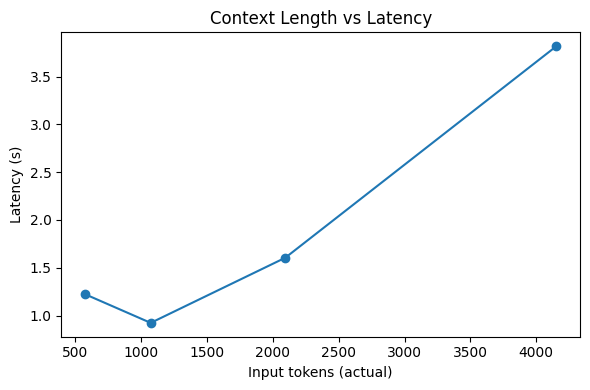

In [41]:
# 1. Context length vs latency
plt.figure(figsize=(6, 4))
plt.plot(context_experiment_df["actual_input_tokens"], context_experiment_df["latency_sec"], marker="o")
plt.xlabel("Input tokens (actual)")
plt.ylabel("Latency (s)")
plt.title("Context Length vs Latency")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "context_length_vs_latency.png"))
plt.show()


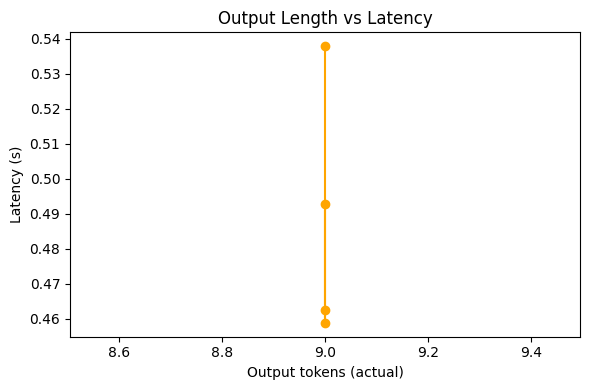

In [42]:
# 2. Output tokens vs latency
plt.figure(figsize=(6, 4))
plt.plot(output_experiment_df["actual_output_tokens"], output_experiment_df["latency_sec"], marker="o", color="orange")
plt.xlabel("Output tokens (actual)")
plt.ylabel("Latency (s)")
plt.title("Output Length vs Latency")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "output_length_vs_latency.png"))
plt.show()


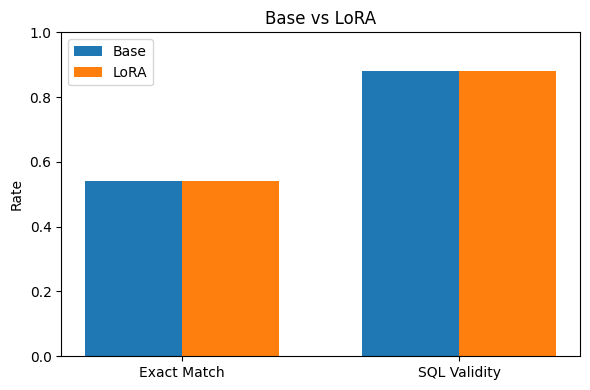

In [43]:
# 3. Base vs LoRA accuracy (exact match + SQL validity)
labels = ["Exact Match", "SQL Validity"]
base_vals = [base_exact_match_acc, base_sql_valid_rate]
lora_vals = [lora_exact_match_acc, lora_sql_valid_rate]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, base_vals, width, label="Base")
plt.bar(x + width/2, lora_vals, width, label="LoRA")
plt.xticks(x, labels)
plt.ylabel("Rate")
plt.ylim(0, 1)
plt.title("Base vs LoRA")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "base_vs_lora_accuracy.png"))
plt.show()


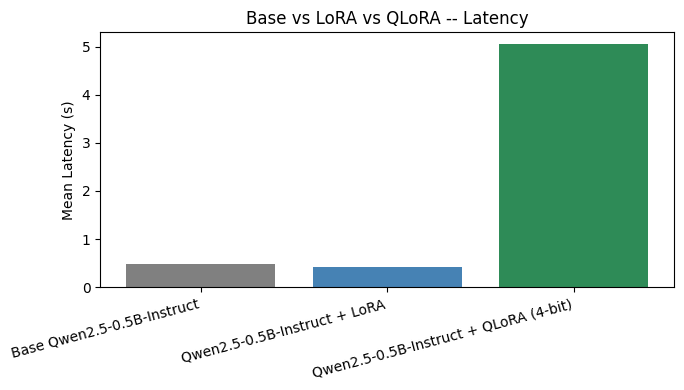

In [44]:
# 4. LoRA vs QLoRA (only if QLoRA actually ran)
if QLORA_AVAILABLE and qlora_model is not None:
    compare_labels = lora_vs_qlora_df["model"].tolist()
    latencies = lora_vs_qlora_df["mean_latency_sec"].tolist()

    plt.figure(figsize=(7, 4))
    plt.bar(compare_labels, latencies, color=["gray", "steelblue", "seagreen"])
    plt.ylabel("Mean Latency (s)")
    plt.title("Base vs LoRA vs QLoRA -- Latency")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "lora_vs_qlora_latency.png"))
    plt.show()
else:
    print("QLoRA did not run in this environment, so this plot is skipped (not fabricated).")


## 33. Save Results

Final directory layout (all created automatically, no hard-coded paths that
assume a specific machine):

```
project/
    data/                         (reserved -- dataset is streamed from the Hub, not duplicated here)
    results/
        base_vs_lora_eval.csv
        latency_base.csv
        latency_lora.csv
        context_length_experiment.csv
        output_length_experiment.csv
        final_results.csv
    plots/
        token_length_distribution.png
        context_length_vs_latency.png
        output_length_vs_latency.png
        base_vs_lora_accuracy.png
        lora_vs_qlora_latency.png        (only if QLoRA ran)
    qwen_sql_lora_adapter/
        adapter_model.safetensors
        adapter_config.json
        (tokenizer files)
    qwen_sql_qlora_adapter/          (only if QLoRA ran)


In [46]:
run_config = {
    "model_name": MODEL_NAME,
    "dataset_name": "b-mc2/sql-create-context",
    "seed": SEED,
    "n_train": N_TRAIN,
    "n_test": N_TEST,
    "max_seq_len": MAX_SEQ_LEN,
    "lora_r": lora_config.r,
    "lora_alpha": lora_config.lora_alpha,
    "lora_dropout": lora_config.lora_dropout,
    "lora_target_modules": lora_config.target_modules,
    "device": DEVICE,
    "qlora_ran": bool(QLORA_AVAILABLE and qlora_model is not None),
}

with open(os.path.join(RESULTS_DIR, "run_config.json"), "w") as f:
   json.dump(run_config, f, indent=2)

print("Saved run configuration to:", os.path.join(RESULTS_DIR, "run_config.json"))
print(json.dumps(run_config, indent=2))

print("\nAll result files in project/results:")
for fname in sorted(os.listdir(RESULTS_DIR)):
    print(" -", fname)

print("\nAll plot files in project/plots:")
for fname in sorted(os.listdir(PLOTS_DIR)):
    print(" -", fname)


TypeError: Object of type set is not JSON serializable

## 34. Final Architecture (Full Pipeline Recap)

```
                SQL Create Context Dataset
                          |
                   Data Formatting (chat template)
                          |
                     Tokenization (label masking)
                          |
                  Qwen2.5-0.5B-Instruct (frozen)
                          |
                     LoRA Adapter (trainable, low-rank)
                          |
                     Fine-Tuning (Trainer, cross-entropy on answer tokens)
                          |
                 Saved LoRA Adapter (safetensors + config)
                          |
              Base Qwen + LoRA Adapter (reloaded fresh)
                          |
                     SQL Output
                          |
             +------------+------------+
             |                         |
        Accuracy                    Latency
             |                         |
   Exact Match / SQL Validity     Base vs LoRA benchmark
                                        |
                            Context-length / Output-length experiments
                                        |
                                     QLoRA (optional, 4-bit)
```


## 35. Future UI (Sketch Only)

The core deliverable of this project is the fine-tuning + optimization
pipeline above, not a UI. This section only **sketches** how a simple
Gradio interface could later wrap the `finetuned_model` + `generate_sql()`
function we already built -- it is not run as part of the main pipeline.

Conceptual layout:

```
Database Schema
[ text area ]

Question
[ text area ]

[ Generate SQL ]

Generated SQL
[ result ]

Latency
Input Tokens
Output Tokens
```


In [ ]:
# OPTIONAL / NOT EXECUTED BY DEFAULT.
# Uncomment and run this cell (after installing gradio: `!pip install -q gradio`)
# to launch a minimal demo UI around the fine-tuned model.
#
# import gradio as gr
#
# def ui_generate(schema, question):
#     result = generate_sql(finetuned_model, tokenizer, schema, question, max_new_tokens=64)
#     info = "Latency: {:.3f}s | Input tokens: {} | Output tokens: {}".format(
#         result["latency_sec"], result["input_tokens"], result["output_tokens"])
#     return result["generated_sql"], info
#
# demo = gr.Interface(
#     fn=ui_generate,
#     inputs=[gr.Textbox(label="Database Schema", lines=4),
#             gr.Textbox(label="Question")],
#     outputs=[gr.Textbox(label="Generated SQL"), gr.Textbox(label="Stats")],
#     title="Text-to-SQL (Qwen2.5-0.5B + LoRA)",
# )
# demo.launch()
print("UI sketch only -- not executed. See the commented code above.")


## 36. How I Would Explain This Project to My Technical Lead

**1. Problem:** Turn natural-language questions about a database into
correct SQL queries, given the relevant schema.

**2. Why Text-to-SQL:** It's a well-defined, evaluable instruction-following
task with a clear input (schema + question) and output (SQL), and a public
dataset already exists for it, so we can focus on the fine-tuning/
optimization pipeline rather than data collection.

**3. Why Qwen2.5-0.5B-Instruct:** It's small enough to fully fit the
pipeline (loading, LoRA fine-tuning, inference, multiple experiments) inside
a single Colab session with modest hardware, and it's already
instruction-tuned, so we're doing targeted domain adaptation rather than
teaching it to follow instructions from nothing. The trade-off is lower raw
capability than a larger model -- explicitly acceptable since the goal is
understanding the pipeline, not maximizing accuracy.

**4. Why an existing dataset:** `b-mc2/sql-create-context` already provides
matched (schema, question, SQL) triples, letting us focus engineering effort
on the fine-tuning/evaluation/optimization pipeline instead of data
collection and labeling.

**5. Why LoRA:** Full fine-tuning would update every one of the ~500M base
parameters, which is memory-heavy and risks overfitting on a small (300
example) dataset. LoRA freezes the base model and trains a small number of
additional low-rank parameters instead.

**6. How LoRA works:** For a frozen weight matrix `W`, LoRA learns an update
`ΔW = B @ A` where `A` and `B` are much lower rank than `W`. The model
computes `W x + B(A x)` -- the frozen path plus a small trainable
correction.

**7. What's frozen:** All original Qwen2.5-0.5B weights.

**8. What's trained:** Only the LoRA `A`/`B` matrices inserted into the
attention projection layers (`q_proj`, `k_proj`, `v_proj`, `o_proj`) -- a
small fraction of total parameters (we report the exact percentage in
Section 19).

**9. What the adapter contains:** Just the learned `A`/`B` matrices plus the
config describing how/where they attach (rank, alpha, target modules) --
not a copy of the base model.

**10. What QLoRA changes:** The frozen base model is loaded in 4-bit
quantized precision instead of full/half precision; LoRA training proceeds
the same way on top of it. This reduces the memory footprint of the frozen
weights.

**11. Why quantization helps:** Storing/computing frozen weights in fewer
bits reduces GPU memory usage, which matters most when fine-tuning much
larger models than our 0.5B example on limited hardware.

**12. How the model is evaluated:** Held-out test set (never seen in
training); we report exact-match accuracy (strict, string-based) and
schema-only SQL validity (does the generated SQL execute without error
against the schema) -- and we explicitly do not claim true "execution
accuracy" since the dataset has no row data to check results against.

**13. How latency is measured:** Warm-up runs excluded, multiple timed
trials, identical prompts/settings across models being compared.

**14. How context affects latency:** Longer input increases prefill cost
(more tokens to process before generation starts) and attention
memory/compute -- we measured this directly rather than assuming it.

**15. How output length affects latency:** Generation is autoregressive
(one token at a time, each depending on all previous ones), so latency
scales roughly with the number of tokens generated -- also measured
directly.

**16. What we learned:** [Fill this in from your own printed results after
running the notebook -- e.g., did LoRA measurably improve exact match / SQL
validity over base? How much did LoRA reduce trainable parameters? How did
latency scale with context/output length? Did QLoRA run in your
environment, and if so, how did its accuracy/latency compare to LoRA?]


## 37. Interview / Technical Questions

Concise, technically accurate answers you should be able to give from
memory after building this project.

**1. Why did you choose Qwen2.5-0.5B-Instruct?** Small enough to run the
full pipeline (load, LoRA train, evaluate, benchmark, QLoRA) in a Colab
session quickly, and already instruction-tuned, so I'm doing targeted
adaptation, not teaching it to follow instructions from scratch.

**2. Why not use a larger model?** Larger models would likely give better
SQL accuracy but cost far more time/memory per experiment, which conflicts
with the goal of running many controlled experiments end-to-end quickly.

**3. What is Text-to-SQL?** Translating a natural-language question, given a
database schema, into an executable SQL query.

**4. What is fine-tuning?** Continuing to train an already-trained model's
weights on new, typically narrower data so it specializes to a task.

**5. What is supervised fine-tuning?** Fine-tuning using labeled
input->output pairs (here: schema+question -> SQL) with a supervised loss
(cross-entropy on the target tokens).

**6. What is instruction tuning?** A form of SFT where the model is trained
to follow instructions phrased conversationally (system/user/assistant
turns) rather than just continuing arbitrary text.

**7. What is LoRA?** A parameter-efficient fine-tuning method that freezes
the base model and learns a low-rank update `ΔW = B @ A` for selected
weight matrices instead of updating all weights directly.

**8. Why use LoRA instead of full fine-tuning?** Far fewer trainable
parameters -> less memory, faster training, lower overfitting risk on a
small dataset, and the base model's original knowledge stays intact.

**9. What does low-rank mean?** `ΔW` is expressed as the product of two
much smaller matrices, so it can't represent arbitrary full-rank updates --
only updates within a much smaller-dimensional subspace, controlled by `r`.

**10. Explain `W' = W + ΔW`.** `W` is the frozen original weight; `ΔW` is
the update learned during fine-tuning; `W'` is the effective weight used at
inference. In LoRA, `ΔW = B @ A` and only `A`, `B` are trained.

**11. What does `r` mean?** The rank of the LoRA update matrices -- controls
adapter expressiveness and trainable parameter count.

**12. What does `lora_alpha` mean?** A scaling factor for the LoRA update
(`scaling = lora_alpha / r`), controlling how strongly the adapter's output
contributes relative to the frozen base output.

**13. What does `lora_dropout` mean?** Dropout applied within the LoRA path
during training, as regularization against overfitting.

**14. What are `target_modules`?** The specific linear layers LoRA is
attached to -- here, the attention projections `q_proj`, `k_proj`,
`v_proj`, `o_proj`.

**15. Which Qwen modules did you target?** The four self-attention
projection layers, identified by inspecting the model's actual `Linear`
submodule names rather than guessing.

**16. Why those modules?** They directly control how tokens attend to each
other, which is central to mapping schema/question tokens correctly into
the generated SQL; it's also the standard, well-validated default for LoRA
on decoder-only LLMs.

**17. Which parameters are frozen?** All original Qwen2.5-0.5B weights.

**18. Which parameters are trained?** Only the inserted LoRA `A`/`B`
matrices (see the exact count/percentage printed in Section 19).

**19. What is a LoRA adapter?** The saved `A`/`B` weights plus config
metadata describing how to attach them to a matching base model.

**20. What is QLoRA?** LoRA fine-tuning where the frozen base model is
additionally loaded in 4-bit quantized precision to reduce memory usage.

**21. Difference between LoRA and QLoRA?** Same adapter mechanism; QLoRA
adds 4-bit quantization of the frozen base weights.

**22. What is quantization?** Representing numbers (here, model weights)
with fewer bits than their original precision, trading some numerical
precision for reduced memory/compute footprint.

**23. Why 4-bit quantization?** It substantially shrinks the memory needed
to hold the frozen base model, which is the main bottleneck when fine-tuning
larger LLMs on limited hardware.

**24. What is an instruction-tuned model?** A model further trained (after
pretraining) to follow natural-language instructions/conversational turns,
rather than just predicting likely continuations of arbitrary text.

**25. What is a causal language model?** A model that predicts each next
token using only preceding tokens (left-to-right), the standard setup for
autoregressive generation.

**26. What is tokenization?** Splitting text into sub-word units (tokens)
and mapping them to integer IDs the model operates on.

**27. What are `input_ids`?** The integer token IDs fed into the model.

**28. What is `attention_mask`?** A binary mask indicating which positions
are real tokens (1) versus padding (0), so the model ignores padding.

**29. What are `labels`?** The target token IDs used to compute training
loss; positions we don't want to train on (here, the prompt) are set to
`-100` so PyTorch's cross-entropy loss ignores them.

**30. What is cross-entropy loss?** A measure of how different the model's
predicted next-token probability distribution is from the actual target
token; lower means the model assigned higher probability to the correct
token.

**31. What happens during a forward pass?** Input tokens flow through the
embedding layer, attention/MLP blocks, and language modeling head, producing
predicted next-token logits at each position.

**32. What happens during backpropagation?** Gradients of the loss with
respect to trainable parameters are computed via the chain rule, flowing
backward through the network; with LoRA, gradients are only computed for the
trainable `A`/`B` matrices (frozen weights don't require gradients).

**33. What does the optimizer do?** Uses computed gradients (and the
learning rate) to update trainable parameters in a direction that reduces
the loss (we use AdamW).

**34. What is learning rate?** The step size controlling how much
parameters change per optimizer update.

**35. What is batch size?** The number of training examples processed
together in one forward/backward pass before an optimizer step (with
gradient accumulation, effectively combined over multiple mini-batches).

**36. What is an epoch?** One full pass through the entire training
dataset.

**37. What is gradient accumulation?** Accumulating gradients across
several small mini-batches before performing one optimizer update, to
simulate a larger effective batch size under memory constraints.

**38. Why do we need a separate test set?** To measure performance on data
the model never trained on, which is the only honest signal of
generalization rather than memorization.

**39. What is data leakage?** When information from the test set leaks into
training (directly or via near-duplicates), inflating measured performance
in a way that doesn't reflect real generalization. We explicitly checked for
zero row overlap between our train/test splits.

**40. How do you evaluate Text-to-SQL?** Multiple angles: exact string
match against reference SQL, and execution-based checks (here, limited to
schema-only SQL validity since we lack row data); ideally also true
execution accuracy against populated databases.

**41. Why is exact match insufficient?** Many different SQL strings can be
semantically equivalent (column order, aliasing, formatting), so exact match
under-counts genuinely correct queries.

**42. What is execution accuracy?** Comparing the *result* of executing the
generated SQL against the *result* of executing the reference SQL on real
data -- we note this requires actual row data, which this dataset doesn't
provide, so we report schema-only "SQL validity" instead and are explicit
about that limitation.

**43. What is context length?** The number of tokens in the input we feed
the model before it starts generating.

**44. Does LoRA increase the model's context window?** No. LoRA only adds
trainable low-rank updates to selected weight matrices; it does not change
the model's underlying positional encoding scheme or maximum supported
sequence length.

**45. What is prefill?** The forward pass over the entire input prompt,
performed once before generation begins, building the key/value cache used
during decoding.

**46. What is decoding?** The autoregressive loop generating output tokens
one at a time after prefill.

**47. What is TTFT?** Time-to-first-token -- roughly the time for prefill
plus producing the first generated token; relevant for perceived latency in
interactive use.

**48. Why does longer context increase latency?** More input tokens means
more work during prefill (and higher attention memory/compute), which we
measured directly in Section 27.

**49. Why does longer output increase latency?** Generation is
autoregressive: each additional output token is one more sequential decoding
step, so latency scales roughly with `max_new_tokens` (measured in
Section 28).

**50. What is tokens-per-second?** Output tokens generated divided by
generation latency -- a throughput metric for decoding speed.

**51. What is overfitting?** When a model fits the training data (including
its noise/quirks) so closely that it performs worse on unseen data; a risk
we mitigate here via LoRA's small parameter count, dropout, and few epochs
on our small training set.

**52. How do you know fine-tuning helped?** By comparing base vs. LoRA on
the *same held-out test set*, using the *same prompts and decoding
settings*, and looking at the actual measured exact-match/SQL-validity/
latency numbers in Sections 24-25 -- not by assumption.

**53. What actually changes inside the model after LoRA?** Nothing in the
original weights changes; new low-rank `A`/`B` matrices are added alongside
the targeted attention projections, and their outputs are added into the
forward pass.

**54. Difference between fine-tuning and RAG?** Fine-tuning changes model
weights to internalize task-specific patterns; RAG (retrieval-augmented
generation) instead retrieves relevant external information at inference
time and inserts it into the prompt, without changing the model's weights.
They can be combined.

**55. Why are we giving the database schema to the model?** The model has
no other way to know table/column names for a specific database; the schema
is the necessary grounding information for producing a valid query.

**56. Why don't we train the LLM from scratch?** Pretraining from scratch
requires vastly more data and compute than fine-tuning; reusing an
already-capable instruction-tuned model and adapting it is far more
efficient for a narrow downstream task.

**57. What are the limitations of using only 300 training examples?**
Limited coverage of SQL patterns/schema variety, higher risk of overfitting
to specific phrasings, and results that may not generalize as well as a
model trained on a much larger set.

**58. How would you improve the project with more compute/data?** Use the
full dataset (or a much larger subset), a larger base model, more epochs
with proper validation-based early stopping, true execution-accuracy
evaluation against populated databases, and broader hyperparameter search
(rank, alpha, target modules, learning rate).

**59. How would you deploy this model?** Serve the frozen base model once,
and load the small LoRA adapter on top (or merge it in) behind an inference
API; a quantized (QLoRA-trained or post-training quantized) variant reduces
serving memory footprint.

**60. How would you optimize inference in production?** Batch requests,
use KV-caching (already implicit in `generate`), consider speculative
decoding or a smaller/distilled model for latency-sensitive paths, quantize
for memory/throughput, and cap `max_new_tokens` appropriately per use case,
informed by experiments like the context/output-length ones run in this
notebook.


## Appendix: How to Run This Notebook

### 1. How to run
1. Open in Google Colab.
2. `Runtime -> Change runtime type -> GPU` (T4 or better recommended).
3. `Runtime -> Run all`, or run cells top to bottom -- later sections depend
   on variables/models created earlier (this notebook is meant to be run in
   order, not cell-by-cell out of sequence).

### 2. Expected runtime for major sections (rough, GPU-dependent; a free
Colab T4 as reference)
- Sections 1-10 (setup, install, load model, baseline inference): ~2-5 min
  (mostly the `pip install` and first model download).
- Sections 11-15 (dataset load/format/tokenize/length analysis): ~1 min.
- Sections 16-20 (LoRA config + training, 300 examples x 2 epochs): ~3-8 min
  on a T4-class GPU; much longer (many minutes) on CPU, which is why the
  notebook automatically caps training steps when no GPU is present.
- Sections 21-24 (save/reload adapter, fine-tuned inference, base vs LoRA
  eval over 50 test examples x 2 models): ~2-5 min.
- Section 25 (SQL correctness evaluation): seconds (CPU-only SQLite checks).
- Sections 26-28 (latency, context-length, output-length experiments):
  ~2-5 min combined.
- Section 29 (QLoRA, optional): ~1 min to install/check `bitsandbytes`, plus
  ~3-8 min of training time if it runs.
- Sections 30-33 (comparison table, final results, plots, saving): under a
  minute.
- Sections 34-37 (architecture recap, UI sketch, explanations, Q&A): no
  computation, reading only.

**Total, with a working GPU:** roughly 15-30 minutes end-to-end.

### 3. Which cells require GPU
- Strictly require GPU to be *fast enough to be practical*: Section 20
  (Fine-Tuning), Section 29 (QLoRA).
- Benefit from GPU but will still run (slowly) on CPU: Sections 8-9, 23-28
  (all inference/benchmarking cells).
- CPU-only, no GPU needed: Sections 10-15 (dataset/tokenization), Section 25
  (SQL validity checks via SQLite), Sections 30-33 (tables/plots/saving).

### 4. Where the LoRA adapter is saved
`project/qwen_sql_lora_adapter/` (adapter weights + config + tokenizer
files). The optional QLoRA adapter, if trained, is saved to
`project/qwen_sql_qlora_adapter/`.

### 5. Where evaluation results are saved
`project/results/` -- `base_vs_lora_eval.csv`, `latency_base.csv`,
`latency_lora.csv`, `context_length_experiment.csv`,
`output_length_experiment.csv`, `final_results.csv`, `run_config.json`.
Plots are saved to `project/plots/`.

### 6. Which cells are optional
- Section 29 (QLoRA) and Section 30's QLoRA row -- guarded to skip cleanly
  if the environment doesn't support it.
- Section 35 (Future UI) -- code is commented out by design; not meant to
  run automatically.

### 7. Checklist: what you should be able to explain after this project
- [ ] Why we picked Qwen2.5-0.5B-Instruct and `b-mc2/sql-create-context`,
      and the trade-offs of using a small model/subset.
- [ ] What a causal, instruction-tuned language model is.
- [ ] Why/how the chat template matters for prompting Qwen correctly.
- [ ] How we prevented train/test data leakage.
- [ ] What LoRA is, the `W' = W + ΔW = W + BA` idea, and what `r`,
      `lora_alpha`, `lora_dropout`, and `target_modules` each control.
- [ ] Why we inspected the model's actual module names instead of guessing
      `target_modules`.
- [ ] The actual trainable-parameter count/percentage LoRA produced on this
      model (from Section 19's output).
- [ ] What happens during a forward pass, loss computation, backprop, and
      optimizer step -- and why only LoRA parameters receive updates.
- [ ] Why we save/reload the adapter separately from the base model.
- [ ] The difference between exact match and (schema-only) SQL validity,
      and why true execution accuracy wasn't possible with this dataset.
- [ ] How we measured latency fairly (warm-up, fixed prompts/settings,
      multiple trials).
- [ ] Why longer input context and longer output length each increase
      latency, and what your own measured plots showed.
- [ ] What QLoRA changes relative to LoRA, and whether/why it ran (or
      didn't) in your environment.
- [ ] Your own project's actual final results table (Section 31) -- be
      ready to state real numbers, not descriptions.
